# *Proyecto de Machine Learning*
--- 

  ###  📌 *Objetivo del Proyecto*
*El objetivo principal de este proyecto ha sido desarrollar un modelo de aprendizaje automático capaz de predecir el precio de una propiedad listada en Airbnb a partir de un conjunto de datos reales obtenidos mediante técnicas de scraping. A diferencia de datasets artificiales o académicos, este conjunto presenta un elevado grado de desorganización y ruido, lo cual supone un reto realista y enriquecedor, obligando a aplicar no solo conocimientos técnicos, sino también juicio crítico y metodológico en cada etapa.*

- *Dado un `.csv` de AirBnb, cree un modelo de regresion predictivo de ML para el precio.*
  



In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Cargamos los datos
df = pd.read_csv("C:\\Users\\oridi\\Desktop\\Programacion\\Machine Learning\\Machine-Learning-101-main\\Proyecto\\Proyecto\\airbnb-listings-extract.csv", sep = ';')

## *1era Parte: EDA*

- ***Split: Test y Train:***
  * **¿Por qué dividimos el dataset al principio?** ->*Porque queremos simular un entorno de producción real, donde nuestro modelo se enfrentará a datos nunca vistos. Si limpiamos, transformamos o seleccionamos variables usando todo el dataset completo, estamos permitiendo que el modelo tenga información de test durante el entrenamiento, lo que genera fugas de datos (data leakage) y resultados artificialmente buenos.*
  
- ***Analisis Estadisitico: Medidas de dispersion y localizacion***:
  * *El Análisis Estadístico Exploratorio (EDA) busca entender la estructura, patrones y comportamiento de los datos antes de aplicar modelos. No se trata solo de observar "números", sino de comprender el contexto y calidad de los datos, anticiparse a posibles problemas (outliers, sesgos, valores faltantes, etc.) y tomar decisiones más informadas durante la limpieza, transformación y modelado.*

---

In [3]:
#Split
train, test = train_test_split(df, test_size=0.2, shuffle=True, random_state=0)

# Guardamos
train.to_csv('C:\\Users\\oridi\Desktop\\Programacion\\Machine Learning\\Machine-Learning-101-main\\Proyecto\\ML-Practica-Train.csv', sep=';', decimal='.', index=False)
test.to_csv('C:\\Users\\oridi\\Desktop\\Programacion\\Machine Learning\\Machine-Learning-101-main\\Proyecto\\ML-Practica-Test.csv', sep=';', decimal='.', index=False)

<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\oridi\AppData\Local\Temp\ipykernel_63752\539017399.py:5: SyntaxWarning: invalid escape sequence '\D'
  train.to_csv('C:\\Users\\oridi\Desktop\\Programacion\\Machine Learning\\Machine-Learning-101-main\\Proyecto\\ML-Practica-Train.csv', sep=';', decimal='.', index=False)


- ***¿Por qué usamos shuffle=True?***: *garantizamos que la división sea aleatoria y balanceada, mezclando los registros y asegurando una distribución más representativa.*
- ***¿Por qué usamos random_state=42?***: *El parámetro `random_state` actúa como una semilla para el generador de números aleatorios, lo que asegura que la división aleatoria sea reproducible.*

In [4]:
print(f'🔎 Dimensiones del dataset de training: {train.shape}')
print(f'🔎 Dimensiones del dataset de test: {test.shape}')

🔎 Dimensiones del dataset de training: (11824, 89)
🔎 Dimensiones del dataset de test: (2956, 89)


In [5]:
# Cargamos datos solo de TRAIN
df_train = pd.read_csv("C:\\Users\\oridi\\Desktop\\Programacion\\Machine Learning\\Machine-Learning-101-main\\Proyecto\\ML-Practica-Train.csv", sep=';', decimal='.')
df_train.head()

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,5994463,https://www.airbnb.com/rooms/5994463,20170407214119,2017-04-08,PISO ATOCHA- FLAT NEAR ATOCHA .,Piso recién reformado cómoda habitación con ba...,"Un piso muy cómodo en Jerónimos, una de las zo...",Piso recién reformado cómoda habitación con ba...,none,El barrio de Jeronimos es un enclave tranquilo...,...,10.0,10.0,9.0,NaN,NaN,moderate,2.0,0.50,"40.4077318793,-3.68481869733","Host Has Profile Pic,Is Location Exact,Require..."
1,14136180,https://www.airbnb.com/rooms/14136180,20170407214119,2017-04-08,The Palace Sol Madrid.,"Lugares de interés: Plaza Mayor, Plaza del Sol...",El apartamento dispone de un dormitorio indepe...,"Lugares de interés: Plaza Mayor, Plaza del Sol...",none,"Situado en el corazón de Madrid, este apartame...",...,10.0,10.0,10.0,NaN,NaN,flexible,1.0,2.43,"40.4158022422,-3.70534037765","Host Has Profile Pic,Host Identity Verified,Re..."
2,15520134,https://www.airbnb.com/rooms/15520134,20170407214119,2017-04-08,por persona la noche metro linea5 vista alegre,"我的房源靠近餐厅和餐饮、适合家庭的活动、公共交通。因为舒适的床、温馨、厨房、景观,您一定会爱...",NaN,"我的房源靠近餐厅和餐饮、适合家庭的活动、公共交通。因为舒适的床、温馨、厨房、景观,您一定会爱...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,moderate,16.0,NaN,"40.3890481626,-3.74037392557","Host Has Profile Pic,Host Identity Verified,Is..."
3,8809721,https://www.airbnb.com/rooms/8809721,20170407214119,2017-04-08,CITY CENTER JACINTO BENAVENTE ROOM4,This stunning and amazig room is covered with ...,NaN,This stunning and amazig room is covered with ...,none,NaN,...,NaN,NaN,NaN,NaN,NaN,strict,97.0,NaN,"40.4128140929,-3.70305247638","Host Has Profile Pic,Requires License"
4,1162707,https://www.airbnb.com/rooms/1162707,20170407214119,2017-04-08,NICE & BIG DOUBLE ROOM AT DOWNTOWN,NaN,We are a young couple; David (Spain) and Ana (...,We are a young couple; David (Spain) and Ana (...,none,NaN,...,10.0,9.0,9.0,NaN,NaN,strict,2.0,2.08,"40.4386311984,-3.71371613279","Host Has Profile Pic,Host Identity Verified,Is..."


In [6]:
print("Estadísticas resumidas para columnas numéricas:")
df_train.describe()

Estadísticas resumidas para columnas numéricas:


,ID,Scrape ID,Host ID,Host Response Rate,Host Listings Count,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,...,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month
count,1.182400e+04,1.182400e+04,1.182400e+04,10317.000000,11821.000000,11821.000000,11824.000000,11824.000000,11824.000000,11780.000000,...,11824.000000,9163.000000,9143.000000,9148.000000,9136.000000,9147.000000,9133.000000,9132.000000,11820.000000,9285.000000
mean,1.025308e+07,2.017038e+13,3.588310e+07,94.803722,12.754420,12.754420,40.491628,-3.776863,3.277486,1.285229,...,22.664834,91.628179,9.410040,9.320726,9.623905,9.647863,9.534655,9.211345,9.615313,1.873326
std,5.566485e+06,5.505346e+08,3.411993e+07,15.247078,34.578895,34.578895,4.701030,14.014695,2.093973,0.664691,...,38.092338,9.137614,0.938013,1.004472,0.804050,0.765450,0.770421,0.963131,23.795580,1.869157
min,1.986400e+04,2.016010e+13,1.745300e+04,0.000000,0.000000,0.000000,-37.851182,-123.124429,1.000000,0.000000,...,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.020000
25%,5.510692e+06,2.017041e+13,6.855490e+06,100.000000,1.000000,1.000000,40.409758,-3.707538,2.000000,1.000000,...,1.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,1.000000,0.450000
50%,1.125754e+07,2.017041e+13,2.454770e+07,100.000000,2.000000,2.000000,40.419331,-3.700763,3.000000,1.000000,...,7.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,2.000000,1.210000
75%,1.531982e+07,2.017041e+13,5.431096e+07,100.000000,6.000000,6.000000,40.430778,-3.683917,4.000000,1.000000,...,27.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000,2.780000
max,1.858361e+07,2.017062e+13,1.247534e+08,100.000000,519.000000,519.000000,55.966912,153.371427,16.000000,8.000000,...,356.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,145.000000,17.210000


In [7]:
#Exploring data
print("\n Tipos de datos:")
print(df_train.dtypes)
print("\n❓ Valores nulos:")
print(df_train.isnull().sum())



 Tipos de datos:
ID                                  int64
Listing Url                        object
Scrape ID                           int64
Last Scraped                       object
Name                               object
                                   ...   
Cancellation Policy                object
Calculated host listings count    float64
Reviews per Month                 float64
Geolocation                        object
Features                           object
Length: 89, dtype: object

❓ Valores nulos:
ID                                   0
Listing Url                          0
Scrape ID                            0
Last Scraped                         0
Name                                 1
                                  ... 
Cancellation Policy                  0
Calculated host listings count       4
Reviews per Month                 2539
Geolocation                          0
Features                             1
Length: 89, dtype: int64


In [8]:
# Verificar filas completas duplicadas
print(f"Filas duplicadas: {df_train.duplicated().sum()}")

Filas duplicadas: 0


In [9]:
 #Cantidad de valores nulos por columna
missing_per_column = df_train.isnull().sum().sort_values(ascending=False)

# Mostrar solo columnas con nulos
print("Valores nulos por columna:")
print(missing_per_column[missing_per_column > 0])

Valores nulos por columna:
Has Availability                  11815
Host Acceptance Rate              11794
Jurisdiction Names                11650
License                           11547
Square Feet                       11350
Monthly Price                      8955
Weekly Price                       8943
Notes                              7281
Security Deposit                   6772
Interaction                        5232
Access                             5161
Cleaning Fee                       4850
Transit                            4581
Neighborhood Overview              4515
Host About                         4160
Neighbourhood                      4159
House Rules                        4143
Space                              3106
Host Neighbourhood                 3082
Review Scores Value                2692
Review Scores Location             2691
Review Scores Checkin              2688
Review Scores Accuracy             2681
Review Scores Communication        2677
Review Scores

In [10]:
# Porcentaje de nulos por columna para visualizacion para rapida de importancia
missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)

print("Porcentaje de nulos por columna:")
print(missing_pct[missing_pct > 0])

Porcentaje de nulos por columna:
Has Availability                  99.923884
Host Acceptance Rate              99.746279
Jurisdiction Names                98.528417
License                           97.657307
Square Feet                       95.991204
Monthly Price                     75.735792
Weekly Price                      75.634303
Notes                             61.578146
Security Deposit                  57.273342
Interaction                       44.248985
Access                            43.648512
Cleaning Fee                      41.018268
Transit                           38.743234
Neighborhood Overview             38.185047
Host About                        35.182679
Neighbourhood                     35.174222
House Rules                       35.038904
Space                             26.268606
Host Neighbourhood                26.065629
Review Scores Value               22.767253
Review Scores Location            22.758796
Review Scores Checkin             22.733424

- *Observamos que tenemos columnas con un elevado porcentaje de nulos, vamos a eliminar directamente aquellas con + de 96% de nulos, ya que, no proporcionan informacion util y generarán ruido/sesgo elevado para nuestro modelo*

- *Tambien vamos a observar las columnas mas en profundidad y asi, evaluar su relevancia para nuestros objetivos de prediccion*


In [11]:
# Umbral de eliminación
threshold = 0.96
# Porcentaje de nulos por columna
missing_ratio = df_train.isnull().mean()
# Columnas a eliminar
cols_to_drop = missing_ratio[missing_ratio > threshold].index

print(f" Eliminando {len(cols_to_drop)} columnas con más del 96% de nulos:")
print(cols_to_drop.tolist())
# Eliminar del dataframe
df_train.drop(columns=cols_to_drop, inplace=True)


 Eliminando 4 columnas con más del 96% de nulos:
['Host Acceptance Rate', 'Has Availability', 'License', 'Jurisdiction Names']


In [12]:
#columnas tipo objeto
object_cols = df_train.select_dtypes(include='object').columns
print(f"\nTotal columnas tipo object: {len(object_cols)}")
print("📦 Columnas tipo objeto:")
print(object_cols)
#columnas tipo numerico
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
print(f"\nTotal columnas tipo numerico: {len(num_cols)}")
print("📦 Columnas tipo numerico:")
print(num_cols)


Total columnas tipo object: 49
📦 Columnas tipo objeto:
Index(['Listing Url', 'Last Scraped', 'Name', 'Summary', 'Space',
       'Description', 'Experiences Offered', 'Neighborhood Overview', 'Notes',
       'Transit', 'Access', 'Interaction', 'House Rules', 'Thumbnail Url',
       'Medium Url', 'Picture Url', 'XL Picture Url', 'Host URL', 'Host Name',
       'Host Since', 'Host Location', 'Host About', 'Host Response Time',
       'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood',
       'Host Verifications', 'Street', 'Neighbourhood',
       'Neighbourhood Cleansed', 'Neighbourhood Group Cleansed', 'City',
       'State', 'Zipcode', 'Market', 'Smart Location', 'Country Code',
       'Country', 'Property Type', 'Room Type', 'Bed Type', 'Amenities',
       'Calendar Updated', 'Calendar last Scraped', 'First Review',
       'Last Review', 'Cancellation Policy', 'Geolocation', 'Features'],
      dtype='object')

Total columnas tipo numerico: 36
📦 Columnas tipo numerico:
Inde

In [13]:
#contenido 
for col in object_cols:
    print(f"\n🔍 {col}:")
    print(df[col].head(1))


🔍 Listing Url:
0    https://www.airbnb.com/rooms/11210388
Name: Listing Url, dtype: object

🔍 Last Scraped:
0    2017-03-07
Name: Last Scraped, dtype: object

🔍 Name:
0    The Loft-Full Bath-Deck w/View
Name: Name, dtype: object

🔍 Summary:
0    Loft in the Hill country 12-15 minutes directl...
Name: Summary, dtype: object

🔍 Space:
0    This loft has a spectacular view of the hills ...
Name: Space, dtype: object

🔍 Description:
0    Loft in the Hill country 12-15 minutes directl...
Name: Description, dtype: object

🔍 Experiences Offered:
0    none
Name: Experiences Offered, dtype: object

🔍 Neighborhood Overview:
0    This neighborhood is located in the hills west...
Name: Neighborhood Overview, dtype: object

🔍 Notes:
0    The loft is located on a gated property.  Ther...
Name: Notes, dtype: object

🔍 Transit:
0    There is no public transportation from this lo...
Name: Transit, dtype: object

🔍 Access:
0    The loft is entirely private to the guest as i...
Name: Access, dtype: obje

In [14]:
df_train['Country Code'].value_counts() #transformaremos mas adelante

Country Code
ES    11203
US      139
GB      127
FR       87
IT       61
AU       38
IE       34
DE       33
AT       26
NL       19
BE       16
CA       16
DK       14
CH        4
GR        3
HK        2
It        1
CU        1
Name: count, dtype: int64

## *2da Parte: Preprocesamiento del Dataset*

1. ***Tratamiento de variables***:
   - *Se descartan columnas con más del 96% de valores nulos, y aquellas irrelevantes (como URLs, descripciones textuales sin estructurar), y otras altamente correlacionadas o redundantes.*
   - *Imputación de valores faltantes: `SimpleImputer` que se usa para rellenar valores faltantes (NaN) de manera automática*
  
2. ***Codificacion de variables***
3. ***Detección y tratamiento de outliers***
4. ***Transformacion de Variables***: *Las variables numéricas se escalaron mediante técnicas como StandardScaler y RobustScaler según su distribución.*
---

* ***Análisis de correlación***: *únicamente el conjunto de entrenamiento (train), para evitar fugas de información y mantener un pipeline limpio, reproducible y válido.*
 

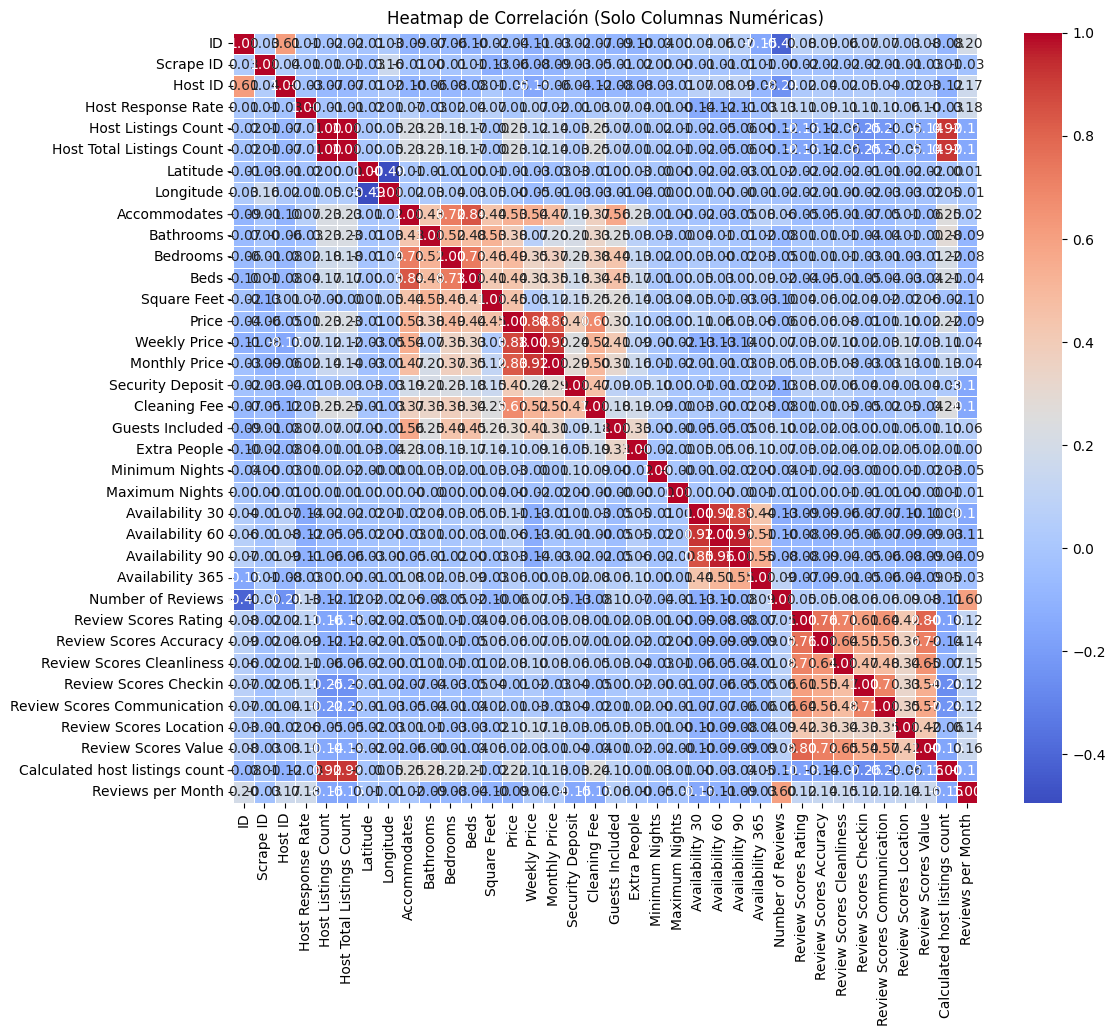

In [15]:
# Correlacion de columnas numéricas
numeric_df = df_train.select_dtypes(include=['int64', 'float64'])
# matriz de correlación
corr_matrix = numeric_df.corr()
# heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap de Correlación (Solo Columnas Numéricas)")
plt.show()

In [16]:
df_train["Host Response Time"].value_counts()

Host Response Time
within an hour        6337
within a few hours    2291
within a day          1448
a few days or more     241
Name: count, dtype: int64

In [17]:
df_train_n=df_train[['Neighbourhood', 'Neighbourhood Cleansed', 'Neighbourhood Group Cleansed']]
len(df_train_n) - df_train_n.count() # vemos cuántos valores NaN hay por columna

Neighbourhood                   4159
Neighbourhood Cleansed             0
Neighbourhood Group Cleansed     818
dtype: int64

*Vamos a eliminar columnas categoricas y numericas con contenido sin valor predictivo:*


- ***No aporta información sobre la propiedad***: , *Scrape ID, Last Scraped, Host ID, Host Name, Host Neighbourhood, Host Listings Count, Host Total Listings Count, Calculated host listings count, Calendar Updated, Calendar last Scraped, First review, Last review, Reviews per Month,Calendar last Scraped*
- ***Urls sin valor***:*Thumbnail Url, Listing Url, Medium Url,Picture Url,XL Picture Url,Host Url, Host Thumbnail Url, Host Picture Url*
- *Weekly Price: información redundante que puede actuar como predictor (y no debe)*
- *Monthly Price: información redundante que puede actuar como predictor (y no debe)*
- *Geolocation: es latitud + longitud*
- *eliminamos 'Country' y nos quedamos con 'Country Code'*

In [18]:
cols_to_drop = [
    'Access', 'Availability 30', 'Availability 60', 'Availability 90', 'Beds', 'Calendar Updated',
    'Calendar last Scraped', 'Calculated host listings count', 'City', 'Country',
    'Description', 'Experiences Offered', 'Features', 'First Review', 'Geolocation', 'Host About',
    'Host ID', 'Host Listings Count', 'Host Location', 'Host Name', 'Host Neighbourhood',
    'Host Picture Url', 'Host Response Time', 'Host Since', 'Host Thumbnail Url',
    'Host Total Listings Count', 'Host URL', 'Host Verifications', 'House Rules', 'ID',
    'Interaction', 'Last Review', 'Last Scraped', 'License', 'Listing Url', 'Market',
    'Medium Url', 'Monthly Price', 'Name', 'Neighborhood Overview', 'Neighbourhood',
    'Neighbourhood Group Cleansed', 'Notes', 'Picture Url', 'Reviews per Month', 'Scrape ID',
    'Smart Location', 'Space', 'State', 'Street', 'Summary', 'Thumbnail Url', 'Transit',
    'Weekly Price', 'XL Picture Url', 'Zipcode'
]

#Elimino Monthly y Weekly price dado que son un 75% de valores nulos y la columna Price está completa -> alta correlacion
#Elimino Country,Country code y City para quedarme con latitude y longitud

df_train.drop(columns=cols_to_drop, axis=1, errors='ignore', inplace=True)
df_train.shape

(11824, 30)

In [19]:
df_train['Bed Type'].value_counts()

Bed Type
Real Bed         11565
Pull-out Sofa      201
Futon               36
Couch               17
Airbed               5
Name: count, dtype: int64

In [20]:
df_train['Accommodates'].value_counts()

Accommodates
2     4227
4     2614
1     1635
3     1140
6      943
5      554
8      267
7      175
10      98
9       59
12      43
16      31
11      19
14      12
15       4
13       3
Name: count, dtype: int64

In [21]:
# Bed Type está muy correlacionada con Accomodates
# Gestion de variables Reviews
reviews = df_train.loc[: , "Review Scores Rating":"Review Scores Value"]
df_train['Average Review'] = reviews.mean(axis=1)

df_train.drop(['Review Scores Rating', 'Bed Type',
         'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin',
         'Review Scores Communication', 'Review Scores Location', 'Review Scores Value'], axis=1, inplace=True)


print(df_train.shape)
print(list(sorted(df_train.columns)))

(11824, 23)
['Accommodates', 'Amenities', 'Availability 365', 'Average Review', 'Bathrooms', 'Bedrooms', 'Cancellation Policy', 'Cleaning Fee', 'Country Code', 'Extra People', 'Guests Included', 'Host Response Rate', 'Latitude', 'Longitude', 'Maximum Nights', 'Minimum Nights', 'Neighbourhood Cleansed', 'Number of Reviews', 'Price', 'Property Type', 'Room Type', 'Security Deposit', 'Square Feet']


In [22]:
# Variables categóricas con pocos valores
cat_cols = [col for col in df_train.select_dtypes(include='object').columns if df_train[col].nunique() < 20]
print(cat_cols)

['Country Code', 'Room Type', 'Cancellation Policy']


In [23]:
train_object_cols = df_train.select_dtypes(include='object').columns
print(f"\nTotal columnas tipo object: {len(train_object_cols)}")
print("📦 Columnas tipo objeto:")
print(train_object_cols)


Total columnas tipo object: 6
📦 Columnas tipo objeto:
Index(['Neighbourhood Cleansed', 'Country Code', 'Property Type', 'Room Type',
       'Amenities', 'Cancellation Policy'],
      dtype='object')


In [24]:
df_train['Property Type'].value_counts()

Property Type
Apartment             9598
House                 1085
Condominium            284
Bed & Breakfast        274
Loft                   248
Other                  171
Dorm                    37
Guesthouse              32
Chalet                  22
Villa                   15
Townhouse               15
Hostel                  13
Serviced apartment       9
Boutique hotel           5
Camper/RV                3
Casa particular          3
Boat                     3
Guest suite              2
Earth House              2
Bungalow                 2
Tent                     1
Name: count, dtype: int64

In [25]:
# Porcentaje de nulos por columna 
missing = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)

print("Porcentaje de nulos por columna:")
print(missing[missing > 0])

Porcentaje de nulos por columna:
Square Feet           95.991204
Security Deposit      57.273342
Cleaning Fee          41.018268
Average Review        22.505074
Host Response Rate    12.745264
Amenities              1.192490
Bathrooms              0.372124
Bedrooms               0.169147
Price                  0.126861
dtype: float64


### *Gestion de missing values*
-  *variables numéricas con la mediana, al ser más robusta ante outliers.*
-  *Variables categoricas con la moda.*

In [26]:
#Gestion de valores nulos
from sklearn.impute import SimpleImputer

# Separar columnas numéricas y categóricas
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
train_object_cols 

# Imputador para numéricos con mediana
num_imputer = SimpleImputer(strategy='median')
df_train[numeric_cols] = num_imputer.fit_transform(df_train[numeric_cols])

# Imputador para categóricos con moda
cat_imputer = SimpleImputer(strategy='most_frequent')
df_train[train_object_cols] = cat_imputer.fit_transform(df_train[train_object_cols])

# Verificamos
missing = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
print("Porcentaje de nulos por columna:")
print(missing[missing > 0])

Porcentaje de nulos por columna:
Series([], dtype: float64)


### *Codificacion*
 - ***¿Por qué es usar `TargetEncoder`?*** :*Aprende los valores de codificación basados en la variable objetivo (Price), lo que le da más poder predictivo y funciona especialmente bien en problemas de regresión.*
 -  ***¿Por qué NO usar `OrdinalEncoder`?***:*debe usarse cuando hay una relación ordenada entre las categorías, y en este caso (por ejemplo, tipos de propiedad), no tiene sentido imponer un orden arbitrario.*

In [27]:
#transformamos square en metro / Recordemos hay 95% nan
def sqft_to_m2(superficie):
    return superficie * 0.3048 * 0.3048

df_train['Square Feet'] = sqft_to_m2(df_train['Square Feet'])

In [28]:
# Target Encoding para variables categóricas
import category_encoders as ce

# Variables categóricas a codificar
target_cols = ['Country Code', 'Room Type', 'Cancellation Policy', 'Amenities', 'Property Type','Neighbourhood Cleansed']
target_encoder = ce.TargetEncoder(cols=target_cols)

# Ajustar el codificador con los datos de entrenamiento
df_train[target_cols] = target_encoder.fit_transform(df_train[target_cols], df_train['Price'])

# Ver las transformaciones aplicadas
for col in target_cols:
    print(f" Codificación por media del target en '{col}':")
    print(df_train[[col]].head())

 Codificación por media del target en 'Country Code':
   Country Code
0     71.774882
1     71.774882
2     71.774882
3     71.774882
4     71.774882
 Codificación por media del target en 'Room Type':
   Room Type
0  95.029064
1  95.029064
2  31.321016
3  40.901141
4  40.901141
 Codificación por media del target en 'Cancellation Policy':
   Cancellation Policy
0            65.061908
1            64.179446
2            65.061908
3            86.946623
4            86.946623
 Codificación por media del target en 'Amenities':
   Amenities
0  71.907817
1  72.861611
2  65.402394
3  65.300044
4  67.846170
 Codificación por media del target en 'Property Type':
   Property Type
0      72.276412
1      72.276412
2      72.276412
3      72.276412
4      72.276412
 Codificación por media del target en 'Neighbourhood Cleansed':
   Neighbourhood Cleansed
0              104.393116
1               85.710220
2               38.256565
3               60.703779
4               56.001975


In [29]:
df_train.dtypes

Host Response Rate        float64
Neighbourhood Cleansed    float64
Country Code              float64
Latitude                  float64
Longitude                 float64
Property Type             float64
Room Type                 float64
Accommodates              float64
Bathrooms                 float64
Bedrooms                  float64
Amenities                 float64
Square Feet               float64
Price                     float64
Security Deposit          float64
Cleaning Fee              float64
Guests Included           float64
Extra People              float64
Minimum Nights            float64
Maximum Nights            float64
Availability 365          float64
Number of Reviews         float64
Cancellation Policy       float64
Average Review            float64
dtype: object

### *Outliers*

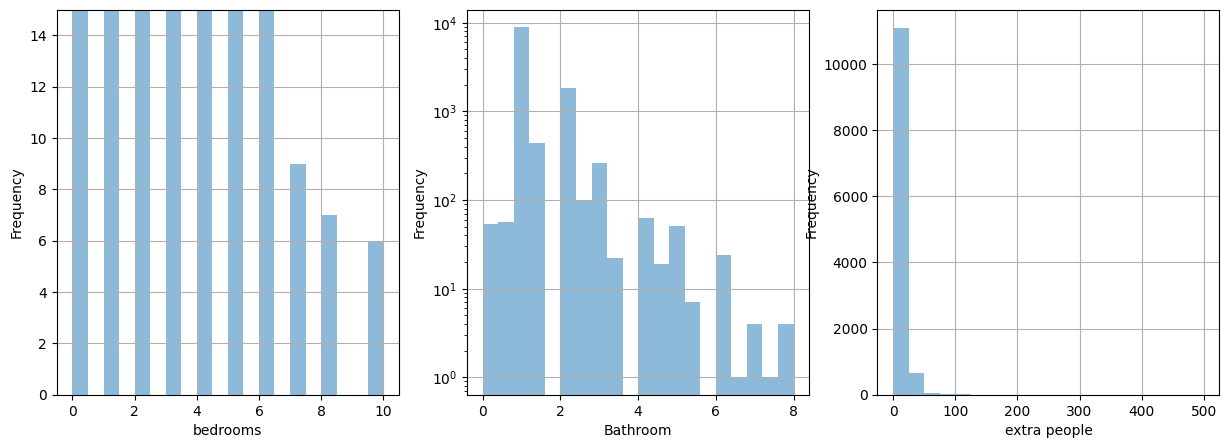

In [30]:
#Pintemos diagramas para: extra people,beds, bathroom,bedrooms, maximun y minimun nights
plt.figure(figsize=(15, 5))
#plt.axis([0, 10, 0, 10000])

plt.subplot(1,3,1)
df_train['Bedrooms'].plot.hist(alpha=0.5, bins=20, grid = True)
plt.ylim(0, 15)
plt.xlabel('bedrooms')

plt.subplot(1,3,2)
df_train['Bathrooms'].plot.hist(alpha=0.5, bins=20, grid = True)
plt.yscale("log")
plt.xlabel('Bathroom')

plt.subplot(1,3,3)
df_train['Extra People'].plot.hist(alpha=0.5, bins=20, grid = True)
plt.xlabel('extra people')

plt.show()

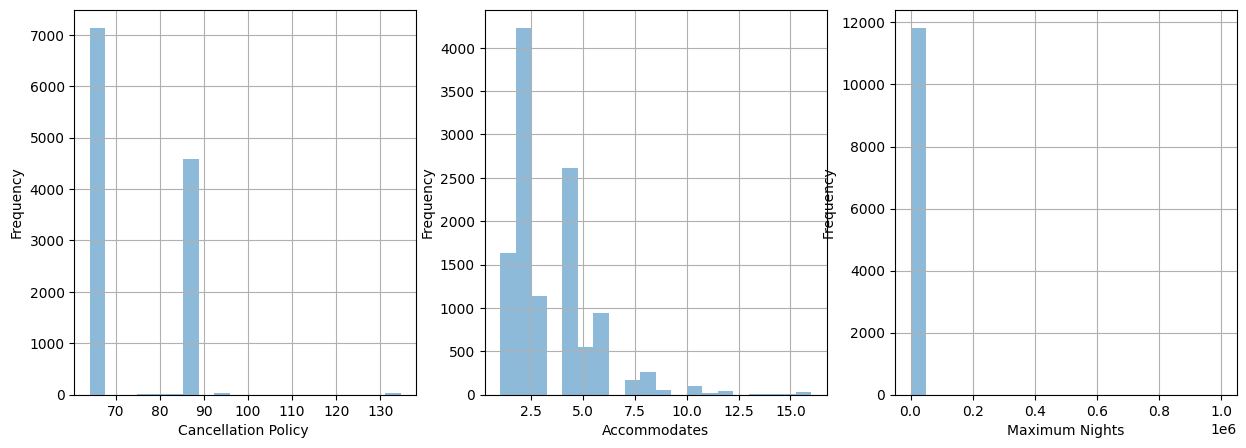

In [31]:
plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
df_train['Cancellation Policy'].plot.hist(alpha=0.5, bins=20, grid = True)
plt.xlabel('Cancellation Policy ')

plt.subplot(1,3,2)
df_train['Accommodates'].plot.hist(alpha=0.5, bins=20, grid = True)
plt.xlabel('Accommodates')

plt.subplot(1,3,3)
df_train['Maximum Nights'].plot.hist(alpha=0.5, bins=20, grid = True)
plt.xlabel('Maximum Nights')

plt.show()

In [32]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Host Response Rate,11824.0,95.466001,14.347284,0.000000,100.000000,100.000000,100.000000,100.000000
Neighbourhood Cleansed,11824.0,71.279594,20.374466,30.614962,60.703779,67.774528,81.915423,190.176421
Country Code,11824.0,73.293803,8.280811,62.002959,71.774882,71.774882,71.774882,182.000484
Latitude,11824.0,40.491628,4.701030,-37.851182,40.409758,40.419331,40.430778,55.966912
Longitude,11824.0,-3.776863,14.014695,-123.124429,-3.707538,-3.700763,-3.683917,153.371427
Property Type,11824.0,73.591219,9.235341,39.558394,72.276412,72.276412,72.276412,145.740406
Room Type,11824.0,73.688854,26.610500,31.321016,40.901141,95.029064,95.029064,95.029064
Accommodates,11824.0,3.277486,2.093973,1.000000,2.000000,3.000000,4.000000,16.000000
Bathrooms,11824.0,1.284168,0.663680,0.000000,1.000000,1.000000,1.000000,8.000000
Bedrooms,11824.0,1.343708,0.904525,0.000000,1.000000,1.000000,2.000000,10.000000


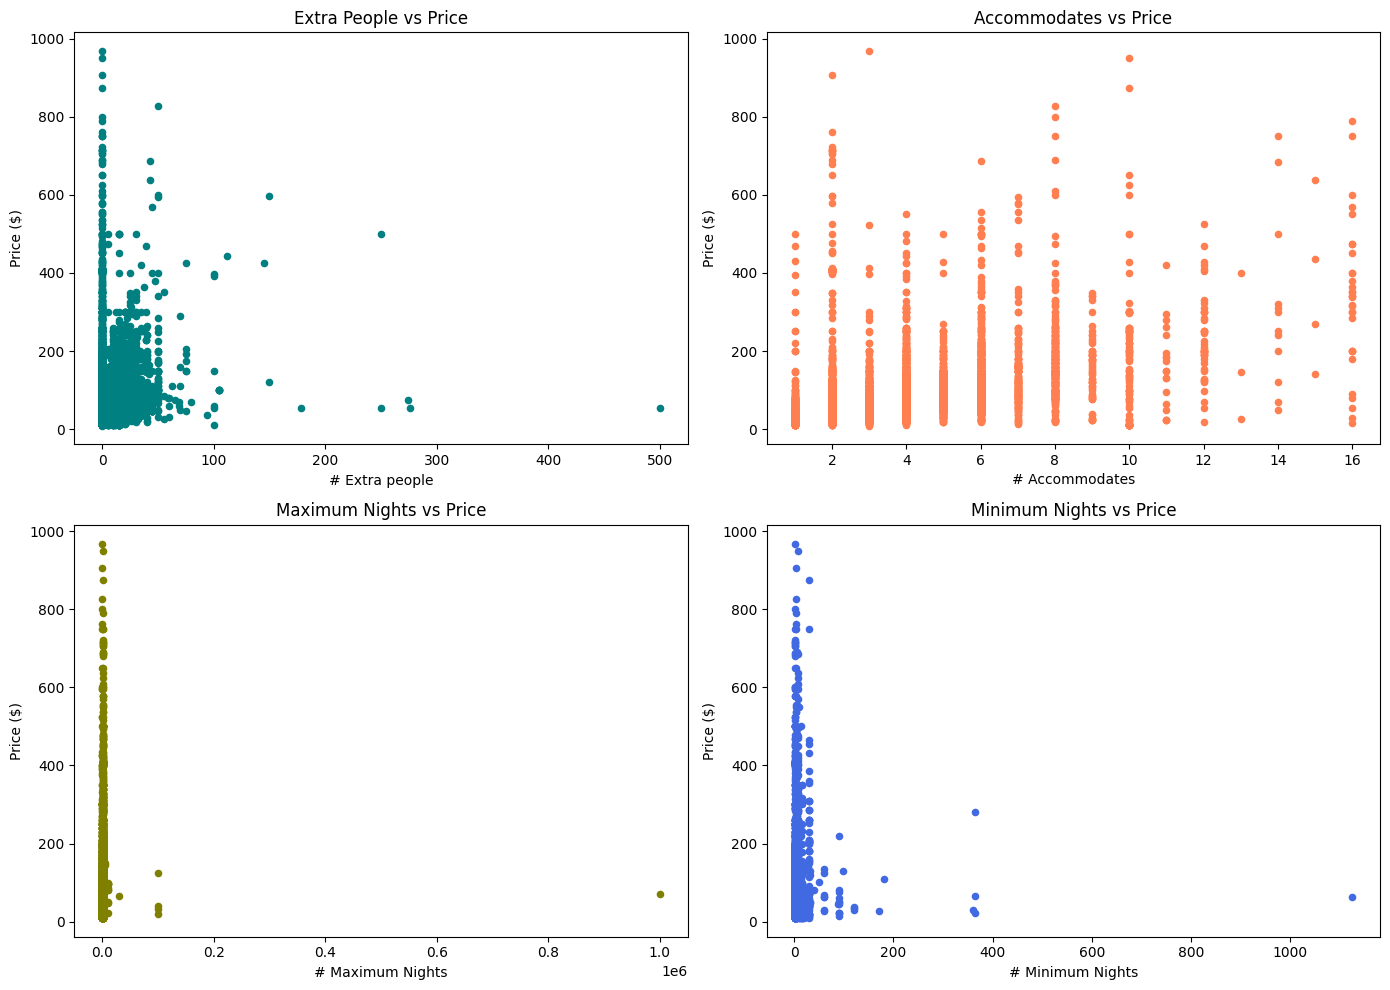

In [33]:
# Crear figura y ejes
fig, axs = plt.subplots(2, 2, figsize=(14, 10))  # 2 filas, 2 columnas

# Scatterplot 1
df_train.plot(kind='scatter', x='Extra People', y='Price', ax=axs[0, 0], color='teal')
axs[0, 0].set_xlabel('# Extra people')
axs[0, 0].set_ylabel('Price ($)')
axs[0, 0].set_title('Extra People vs Price')

# Scatterplot 2
df_train.plot(kind='scatter', x='Accommodates', y='Price', ax=axs[0, 1], color='coral')
axs[0, 1].set_xlabel('# Accommodates')
axs[0, 1].set_ylabel('Price ($)')
axs[0, 1].set_title('Accommodates vs Price')

# Scatterplot 3
df_train.plot(kind='scatter', x='Maximum Nights', y='Price', ax=axs[1, 0], color='olive')
axs[1, 0].set_xlabel('# Maximum Nights')
axs[1, 0].set_ylabel('Price ($)')
axs[1, 0].set_title('Maximum Nights vs Price')

# Scatterplot 4
df_train.plot(kind='scatter', x='Minimum Nights', y='Price', ax=axs[1, 1], color='royalblue')
axs[1, 1].set_xlabel('# Minimum Nights')
axs[1, 1].set_ylabel('Price ($)')
axs[1, 1].set_title('Minimum Nights vs Price')

# Ajustar diseño
plt.tight_layout()
plt.show()


In [34]:
df_train.shape

(11824, 23)

In [35]:
print(len(df_train[df_train['Price'] > 300]))
# Reducir Price
df_train = df_train[df_train['Price'] < 600]

203


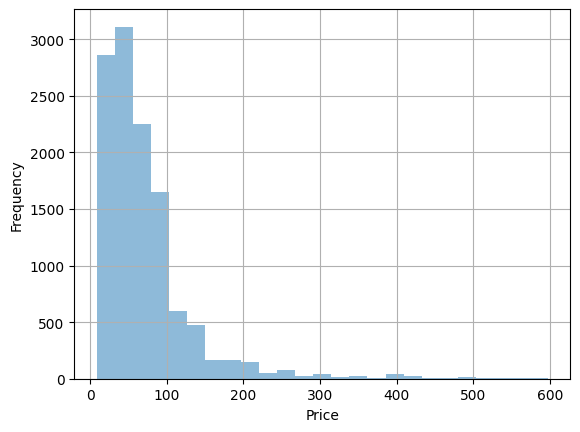

In [36]:
df_train['Price'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.xlabel('Price')

plt.show()

⚠️ *se probaron 2 umbrales de eliminacion, según el objetivo del análisis:*
 - *3, el cual eliminaba: 3139 filas -> lo que equivale al 26% de los datos. se decidió ajustar el umbral.*
 - *4, eliminó el 15% de los datos. Sim embargo, para modelos sensibles a outliers (regresión lineal) suele ser crucial limpiarlos, por lo que tomaremos esta cifra como "aceptable".*


In [37]:
#Gestion de Outliers
from scipy.stats import zscore
# Cols numericas
num_cols = df_train.select_dtypes(include=[np.number]).columns
# Calcular Z-score
z_scores = np.abs(zscore(df_train[num_cols]))
outlier_mask = (z_scores > 4).any(axis=1)  # umbral = 4
print(outlier_mask.value_counts())

# Eliminar outliers
print(f"⚠️ Eliminando {outlier_mask.sum()} filas con outliers (Z-Score)")
df_train = df_train[~outlier_mask]

False    10181
True      1612
Name: count, dtype: int64
⚠️ Eliminando 1612 filas con outliers (Z-Score)


In [38]:
df_train.shape

(10181, 23)

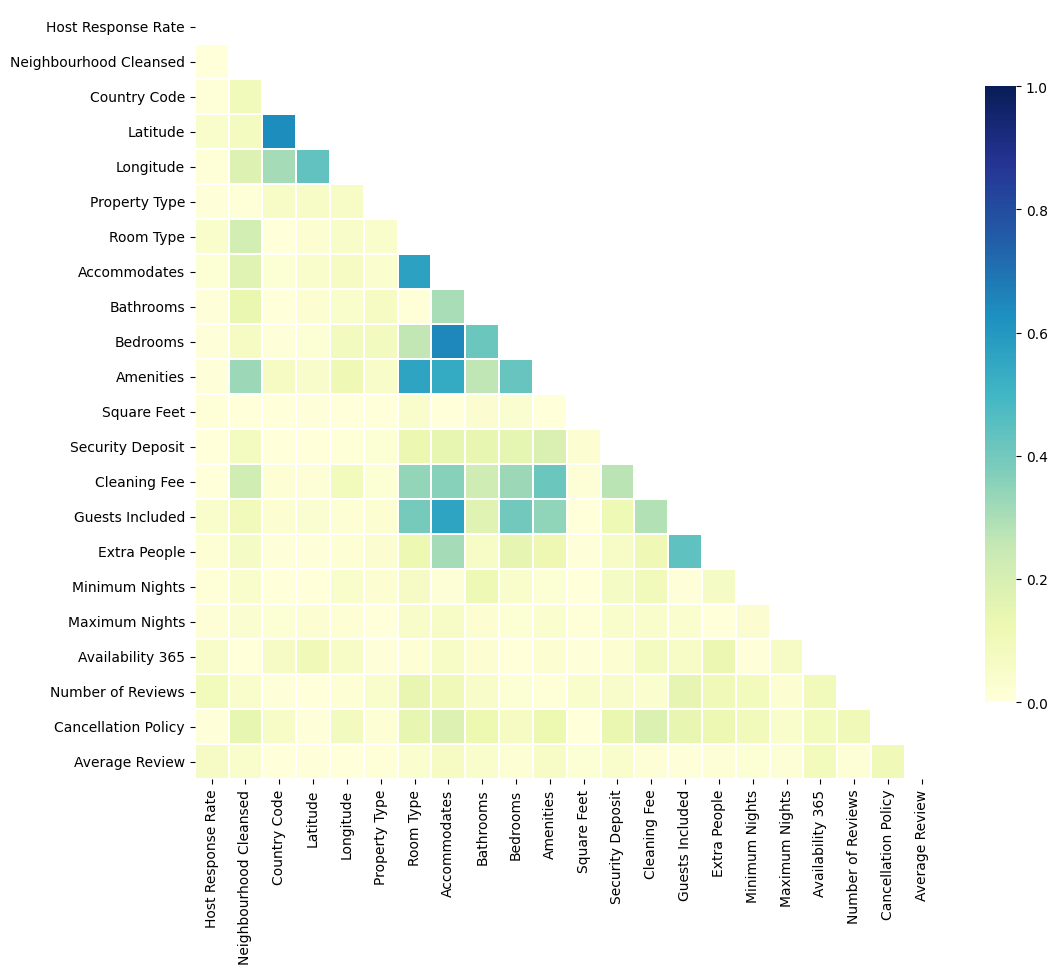

In [39]:
#Correlacion con el precio

corr = np.abs(df_train[num_cols].drop(['Price'], axis=1).corr())

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()


In [40]:
list(df_train.columns.sort_values())

['Accommodates',
 'Amenities',
 'Availability 365',
 'Average Review',
 'Bathrooms',
 'Bedrooms',
 'Cancellation Policy',
 'Cleaning Fee',
 'Country Code',
 'Extra People',
 'Guests Included',
 'Host Response Rate',
 'Latitude',
 'Longitude',
 'Maximum Nights',
 'Minimum Nights',
 'Neighbourhood Cleansed',
 'Number of Reviews',
 'Price',
 'Property Type',
 'Room Type',
 'Security Deposit',
 'Square Feet']

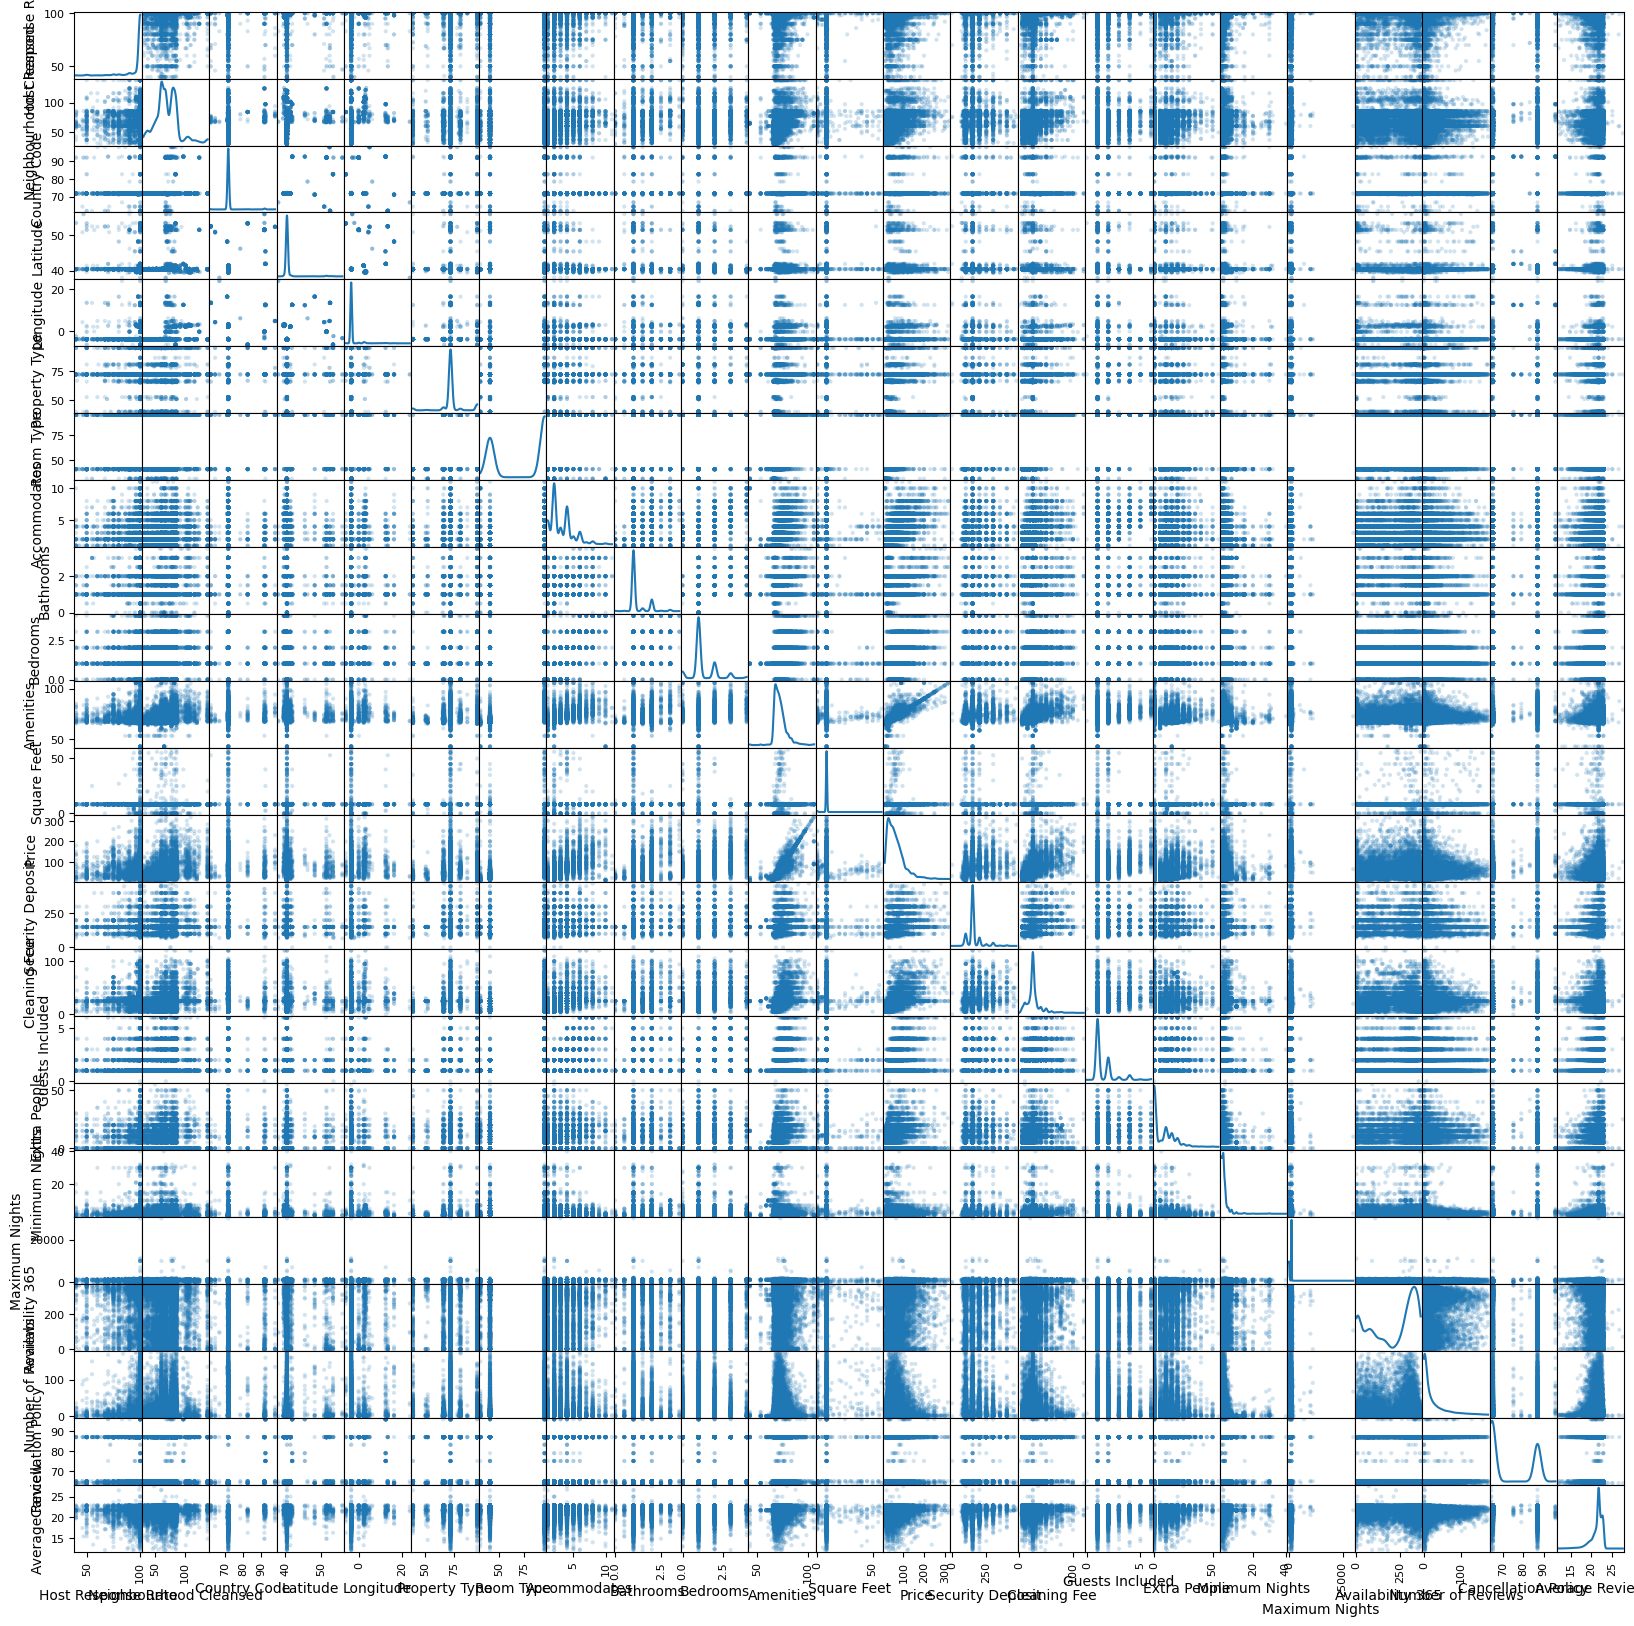

In [41]:
pd.plotting.scatter_matrix(df_train, alpha=0.2, figsize=(20, 20), diagonal = 'kde')
plt.show()

⚠️ *'Amenities' altamente correlacionado*

## *3era Parte: Algoritmos de Machine Learning*


1. ***Escalado y estandarización de datos:*** *necesario para algoritmos sensibles a las magnitudes de las variables como Ridge y Lasso.*
   - ***Transformación de variables***: *transformaciones logarítmicas o polinómicas para mejorar la linealidad y capturar relaciones más complejas.*
  
2. ***Selección y evaluación de modelos:***
   - ***Modelos lineales***: *Ridge y Lasso, ideales cuando existen muchas variables y posible multicolinealidad.*
   - ***Modelos alternativos:*** *se explorarán modelos como DecisionTreeRegressor, RandomForestRegressor y SVR con kernel RBF para capturar relaciones no lineales.*
   - ***Modelos avanzados:*** *se incluirán técnicas más potentes como HistGradientBoostingRegressor, LightGBM y XGBoost, para mejoras sustanciales en rendimiento.*
   - 
3. ***Entrenamiento y métricas:*** Evaluación del rendimientos, validación cruzada y ajuste de hiperparámetros

---


In [42]:
df_train.shape

(10181, 23)

In [43]:
#cargamos datos Test
df_test = pd.read_csv("C:\\Users\\oridi\\Desktop\\Programacion\\Machine Learning\\Machine-Learning-101-main\\Proyecto\\ML-Practica-Test.csv", sep=';', decimal='.')
print('🔍 Explorando dimensiones iniciales:')
print(df_test.shape)

#transformamos square en metro / Recordemos hay 95% nan
def sqft_to_m2(superficie):
    return superficie * 0.3048 * 0.3048

df_test['Square Feet'] = sqft_to_m2(df_test['Square Feet'])

#Variable Reviews
reviews = df_test.loc[: , "Review Scores Rating":"Review Scores Value"]
df_test['Average Review'] = reviews.mean(axis=1)

#Reducimos Price
df_test = df_test[df_test['Price'] < 600]

##Eliminamos colunmas que no nos aportan valor
df_test = df_test.drop(['Access', 'Availability 30', 'Availability 60', 'Availability 90', 'Bed Type', 'Beds',
    'Calendar Updated', 'Calendar last Scraped', 'City', 'Country',
    'Description', 'Experiences Offered', 'Features', 'First Review', 'Geolocation',
    'Has Availability', 'Host Acceptance Rate', 'Host About', 'Host ID', 'Host Listings Count',
    'Host Location', 'Host Name', 'Host Neighbourhood', 'Host Picture Url',
    'Host Response Time', 'Host Since', 'Host Thumbnail Url','Host Total Listings Count',
    'Host URL', 'House Rules', 'ID', 'Interaction', 'Jurisdiction Names', 'Last Review',
    'Last Scraped', 'License', 'Listing Url', 'Market', 'Medium Url', 'Monthly Price',
    'Name', 'Neighborhood Overview', 'Neighbourhood', 'Neighbourhood Group Cleansed',
    'Notes', 'Picture Url', 'Review Scores Accuracy',
    'Review Scores Checkin', 'Review Scores Cleanliness', 'Review Scores Communication',
    'Review Scores Location', 'Review Scores Rating', 'Review Scores Value', 'Reviews per Month',
    'Scrape ID', 'Smart Location', 'Space', 'State', 'Street', 'Summary', 'Thumbnail Url',
    'Transit', 'Weekly Price', 'XL Picture Url', 'Zipcode'
    ], axis =1)


#Gestion de valores nulos

# Separar columnas numéricas y categóricas
cols_num = df_test.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_test.select_dtypes(include='object').columns 

# Imputador para numéricos con mediana
num_imputer = SimpleImputer(strategy='median')
df_test[cols_num] = num_imputer.fit_transform(df_test[cols_num])

# Imputador para categóricos con moda
cat_imputer = SimpleImputer(strategy='most_frequent')
df_test[cat_cols] = cat_imputer.fit_transform(df_test[cat_cols])
# Verificamos
missing = (df_test.isnull().sum() / len(df_test) * 100).sort_values(ascending=False)
print("Confirmacion de nulos por columna:")
print(missing[missing > 0])



# Target Encoding para variables categóricas

# Variables categóricas a codificar
target_cols = ['Country Code', 'Room Type', 'Cancellation Policy', 'Amenities', 'Property Type','Neighbourhood Cleansed']
target_encoder = ce.TargetEncoder(cols=target_cols)

# Ajustar el codificador con los datos de entrenamiento
df_test[target_cols] = target_encoder.fit_transform(df_test[target_cols], df_test['Price'])



#Gestion de Outliers

# Calcular Z-score
z_scores = np.abs(zscore(df_test[cols_num]))
outlier_mask = (z_scores > 4).any(axis=1)  # umbral = 4
print(outlier_mask.value_counts())

# Eliminar outliers
print(f"⚠️ Eliminando {outlier_mask.sum()} filas con outliers (Z-Score)")
df_test = df_test[~outlier_mask]

print("✅ Dimensiones Finales de Test:", df_test.shape)
print("✅ Dimensiones Finales de Train:", df_train.shape)

🔍 Explorando dimensiones iniciales:
(2956, 89)
Confirmacion de nulos por columna:
Series([], dtype: float64)
False    2555
True      388
Name: count, dtype: int64
⚠️ Eliminando 388 filas con outliers (Z-Score)
✅ Dimensiones Finales de Test: (2555, 25)
✅ Dimensiones Finales de Train: (10181, 23)


In [44]:
#Al haber diferencias en el numero de columnas: comprobamos y modificamos

train_cols = set(df_train.columns)
test_cols = set(df_test.columns)

solo_en_train = train_cols - test_cols
solo_en_test = test_cols - train_cols

print("Columnas **solo en train**:", solo_en_train)
print("Columnas **solo en test**:", solo_en_test)

Columnas **solo en train**: set()
Columnas **solo en test**: {'Host Verifications', 'Calculated host listings count'}


In [45]:
df_test= df_test.drop(['Calculated host listings count', 'Host Verifications'],axis=1)
print(df_test.shape)

(2555, 23)


### *Recapitulación General*
- ***Transformaciones coherentes para Train y Test:*** *Hasta este punto, hemos realizado un proceso integral de limpieza y preparación de los datos. Exploramos, eliminamos columnas irrelevantes, filtramos outliers, transformamos las variables (actualmente todas son numéricas) e imputamos valores faltantes usando la mediana para variables numéricas y la moda para las categóricas. Como resultado, hemos conseguido un conjunto de datos más limpio y manejable.*
- ***Variable objetivo:*** *A continuación, procederemos a separar nuestras variables independientes (X) de la variable objetivo (y), que en nuestro caso es el precio del anuncio. Nos enfrentamos a un problema de regresión, por lo que utilizaremos modelos adecuados para este tipo de tareas.*
- ***Preparación para el modelado:*** *Crearemos un diccionario con distintos modelos de regresión para aplicarlos de forma automatizada dentro de un bucle. Antes de entrenar, escalaremos los datos de Train, ya que modelos como Lasso (L1) y Ridge (L2) penalizan los coeficientes de las variables. Si las variables tienen escalas diferentes (por ejemplo, “metros cuadrados” frente a “número de baños”), aquellas con valores más grandes dominarán el proceso de penalización y afectarán negativamente al rendimiento del modelo.*
   - ⚠️ *Importante: solo escalamos el conjunto de entrenamiento para evitar fugas de información.*
  
- ***Evaluación del rendimiento:*** *Evaluaremos nuestros modelos utilizando las siguientes métricas:*
   - 📉 ***Error Cuadrático Medio (MSE)***: *mide la diferencia promedio al cuadrado entre los valores predichos por el modelo y los valores reales.*
   - 📈 ***Coeficiente de Determinación (R²)***: *indica qué proporción de la variabilidad de la variable dependiente es explicada por el modelo.*

- ***Ajuste del modelo:*** *Según los resultados obtenidos, buscaremos mejorar el rendimiento de nuestros modelos aplicando técnicas de ajuste de hiperparámetros (como GridSearchCV), optimizando así su capacidad predictiva.*


---



In [46]:
train_df = df_train
test_df = df_test

#Columna objetivo 'price'
target_col = 'Price'

#Separar variables independientes y dependientes
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("✅ X_train:", X_train.shape)
print("✅ y_train:", y_train.shape)
print("✅ X_test:", X_test.shape)
print("✅ y_test:", y_test.shape)

✅ X_train: (10181, 22)
✅ y_train: (10181,)
✅ X_test: (2555, 22)
✅ y_test: (2555,)


In [47]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import preprocessing

In [48]:
# Diccionario de modelos
modelos = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.1, random_state=42),
    "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

In [49]:
# Escalamos (con los datos de train)
scaler = preprocessing.StandardScaler().fit(X_train)
XtrainScaled = scaler.transform(X_train)

In [50]:
# Escalamos (con los datos de train)
scaler = preprocessing.StandardScaler().fit(X_train)

XtrainScaled = scaler.transform(X_train)
XtestScaled = scaler.transform(X_test) 

print('✅Datos entrenamiento: ', XtrainScaled.shape)
print('✅Datos test: ', XtestScaled.shape)

✅Datos entrenamiento:  (10181, 22)
✅Datos test:  (2555, 22)


best mean cross-validation score: -277.182
best parameters: {'alpha': np.float64(0.03162277660168379)}


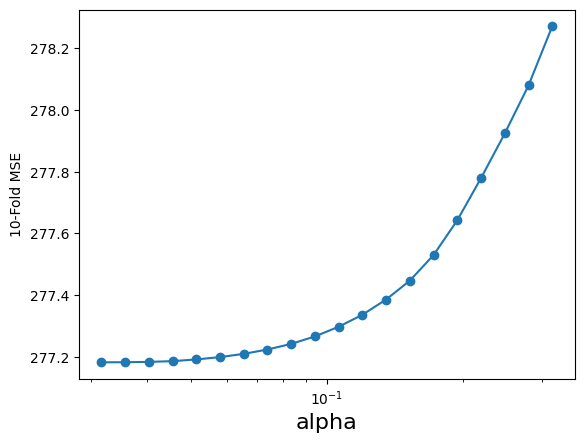

In [51]:
alpha_vector = np.logspace(-1.5,-0.5,20)

param_grid = {'alpha': alpha_vector }
grid = GridSearchCV(Lasso(), scoring= 'neg_mean_squared_error', param_grid=param_grid, cv = 10)
grid.fit(XtrainScaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

scores = -1*np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(alpha_vector,scores,'-o')
plt.xlabel('alpha',fontsize=16)
plt.ylabel('10-Fold MSE')
plt.show()

In [52]:
#Utilizemos los modelos sin escalado
for nombre, modelo in modelos.items():
    print(f"\nEntrenando modelo: {nombre}")
    
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"📉 MSE: {mse:.2f}")
    print(f"📈 R²: {r2:.2f}")


Entrenando modelo: Ridge
📉 MSE: 1383.68
📈 R²: 0.22

Entrenando modelo: Lasso
📉 MSE: 1389.98
📈 R²: 0.22

Entrenando modelo: DecisionTree
📉 MSE: 623.51
📈 R²: 0.65


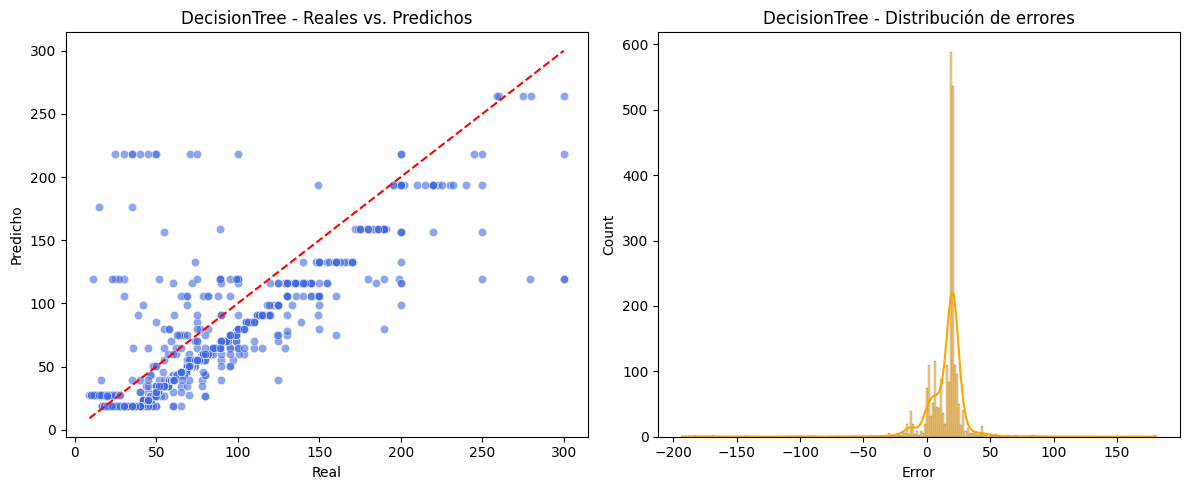

None


In [53]:
def graficar_resultados(y_test, y_pred, nombre_modelo):
    plt.figure(figsize=(12, 5))

    # Reales vs Predichos
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='royalblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Real')
    plt.ylabel('Predicho')
    plt.title(f'{nombre_modelo} - Reales vs. Predichos')

    # Errores (residuos)
    plt.subplot(1, 2, 2)
    errores = y_test - y_pred
    sns.histplot(errores, kde=True, color='orange')
    plt.title(f'{nombre_modelo} - Distribución de errores')
    plt.xlabel('Error')

    plt.tight_layout()
    plt.show()
    
print(graficar_resultados(y_test, y_pred, nombre))

In [54]:
#Ahora veremos los modelos con el escalado
for nombre, modelo in modelos.items():
    print(f"\nEntrenando modelo: {nombre}")
    
    modelo.fit(XtrainScaled, y_train)
    y_pred = modelo.predict(XtestScaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"📉 MSE: {mse:.2f}")
    print(f"📈 R²: {r2:.2f}")


Entrenando modelo: Ridge
📉 MSE: 1383.30
📈 R²: 0.22

Entrenando modelo: Lasso
📉 MSE: 1382.66
📈 R²: 0.22

Entrenando modelo: DecisionTree
📉 MSE: 623.51
📈 R²: 0.65


In [55]:
#  hiperparámetros 
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso()
# objeto GridSearchCV
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error')

# Entrenar el modelo con la búsqueda de hiperparámetros
grid_search.fit(XtrainScaled , y_train)

# Obtener el mejor modelo
best_lasso = grid_search.best_estimator_

# Predecir con el mejor modelo
y_pred = best_lasso.predict(XtestScaled )

# Calcular el MSE y R²
mse = mean_squared_error(y_test, y_pred)
r2 = best_lasso.score(XtestScaled , y_test)

print(f"Mejor valor de alpha: {grid_search.best_params_['alpha']}")
print(f"📉 MSE: {mse}")
print(f"📈 R²: {r2}")

Mejor valor de alpha: 0.01
📉 MSE: 1383.558062993894
📈 R²: 0.2210102821259845


###  ⚠️¡*Atención!*

 *los resultados actuales reflejan un rendimiento bastante bajo para un problema de regresión: un R² de 0.22 indica que el modelo explica apenas un 20% de la variabilidad del precio. Además, el error cuadrático medio es considerablemente alto, incluso ajustando hiperparametros.*
- ***Estrategias a seguir***:
   - *Hacer una transformacion polinómica de las variables predictoras con `PolynomialFeatures`.*
  
   - ***Probar algoritmos de* `Kernel`:*** *Los kernels permiten a los modelos capturar relaciones no lineales entre las variables. Muchas veces, los datos no siguen una relación lineal simple, por lo que el kernel transforma el espacio de características para que un clasificador lineal pueda separar datos complejos. Esto mejora la capacidad predictiva.*
  
   - ***`Boosting`***: *combina múltiples árboles débiles para formar un predictor fuerte, corrigiendo los errores de cada uno. Este tipo de algoritmo captura no linealidades de forma natural, maneja variables categóricas codificadas numéricamente, la capacidad para capturar patrones complejos y se reduce el sesgo y suele mejorar considerablemente el desempeño en regresión.Ejemplos populares incluyen XGBoost y LightGBM.*
  
   - ***`Bagging`(Bootstrap Aggregating)***: *reduce la varianza del modelo al entrenar múltiples instancias del mismo modelo sobre diferentes subconjuntos aleatorios de los datos (con reemplazo). Luego, se combinan los resultados (promediando o votando). Esto ayuda a evitar el sobreajuste y a obtener predicciones más estables y precisas.*
  
   - ***`Random Forest`***:*Es una extensión de bagging que, además de usar distintos subconjuntos de datos, selecciona aleatoriamente subconjuntos de características para construir cada árbol. Esta aleatorización adicional reduce aún más la correlación entre árboles, mejorando la generalización y disminuyendo el sobreajuste en comparación con un solo árbol de decisión.*
  
   - ***`CrossValidation`***: *La validación cruzada ayuda a evaluar el desempeño real del modelo dividiendo los datos en múltiples particiones para entrenamiento y prueba. Esto evita sobreajuste a un solo conjunto y ofrece una estimación más robusta y generalizable del rendimiento. Además, facilita la comparación entre diferentes modelos o configuraciones de hiperparámetros con mayor confianza.*
  

In [56]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


# 1. Transformar el target con log
y_train_log = np.log1p(y_train)  # log(1 + price)
y_test_log = np.log1p(y_test)

# 2. Crear pipeline con PolynomialFeatures y Ridge
pipeline = Pipeline([
    ('scaler', StandardScaler()),                
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # Polinomios grado 2
    ('model', Ridge(alpha=1.0))                  
])

# 3. Entrenar modelo con el target transformado
pipeline.fit(X_train, y_train_log)

# 4. Predecir en test  
y_pred_log = pipeline.predict(X_test)

# 5. Invertir la transformación logarítmica
y_pred = np.expm1(y_pred_log)  # inversa de log1p
y_real = np.expm1(y_test_log)

# 6. Evaluar en la escala original
mse = mean_squared_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)

print(f"📉 MSE: {mse:.2f}")
print(f"📈 R²: {r2:.2f}")

📉 MSE: 687.78
📈 R²: 0.61


📉 MSE para SVR: 569.8080483833448
📈 R² para SVR: 0.6791789063828801


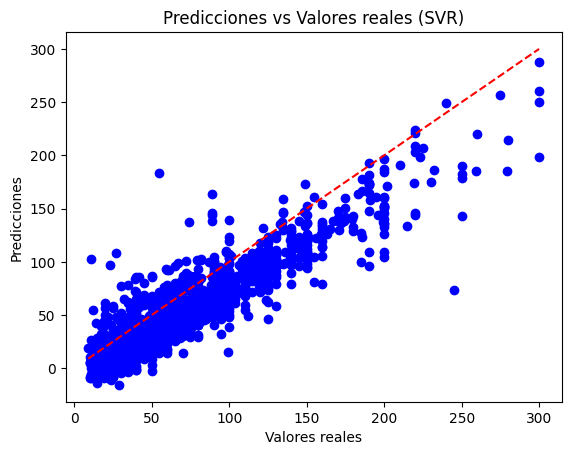

In [57]:
from sklearn.svm import SVR

#Escalar los datos objetivo? no estoy segura de esto!!
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Crear el modelo SVR con un kernel RBF
svr = SVR(kernel='rbf', C=100, epsilon=0.1)

# Entrenar el modelo
svr.fit(XtrainScaled, y_train_scaled.ravel()) 

# Predecir
y_pred_scaled = svr.predict(XtestScaled )

# Desescalar las predicciones para volver a la escala original
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Calcular el MSE y R²
mse_svr = mean_squared_error(y_test, y_pred)
r2_svr = r2_score(y_test, y_pred)

print(f"📉 MSE para SVR: {mse_svr}")
print(f"📈 R² para SVR: {r2_svr}")

# Graficar los resultados
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores reales (SVR)')
plt.show()

In [58]:
#Cross - Validation
from sklearn.pipeline import make_pipeline

# Creamos el pipeline con el escalador y el modelo
model = make_pipeline(StandardScaler(), Ridge())

# Cross-Validation con 5 folds
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

print(f"Scores de MSE por pliegue: {cv_scores}")
print(f"📉 MSE promedio: {-cv_scores.mean()}")

Scores de MSE por pliegue: [-293.12520901 -260.21507147 -244.78829366 -272.76470057 -313.48937183]
📉 MSE promedio: 276.8765293077237


In [59]:
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Modelo base
hgb_model = HistGradientBoostingRegressor(random_state=42)

# 2. Grid de hiperparámetros
hgb_params = {
    'learning_rate': [0.01, 0.1],
    'max_iter': [100, 200],
    'max_leaf_nodes': [31, 50],
    'max_depth': [None, 10]
}

# 3. GridSearchCV
hgb_grid = GridSearchCV(hgb_model, hgb_params, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)
hgb_grid.fit(X_train, y_train)

# 4. Resultados
hgb_best = hgb_grid.best_estimator_
y_pred_hgb = hgb_best.predict(X_test)

print("HistGradientBoosting - Mejor configuración:", hgb_grid.best_params_)
print(f"📉 MSE: {mean_squared_error(y_test, y_pred_hgb):.2f}")
print(f"📈 R²: {r2_score(y_test, y_pred_hgb):.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
HistGradientBoosting - Mejor configuración: {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 200, 'max_leaf_nodes': 31}
📉 MSE: 574.80
📈 R²: 0.6764


In [60]:
from sklearn.ensemble import GradientBoostingClassifier
Niterations = [25,50,75,100]
learningRate = [0.5,0.1,0.05]
# mantenemos max_depth estático: max_depth=2

param_grid = {'n_estimators': Niterations,'learning_rate':learningRate }
grid = GridSearchCV(GradientBoostingClassifier(random_state=0, max_depth=2), param_grid=param_grid, cv = 3, verbose=2)
grid.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\oridi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[CV] END .................learning_rate=0.5, n_estimators=25; total time=  36.8s
[CV] END .................learning_rate=0.5, n_estimators=25; total time=  36.9s
[CV] END .................learning_rate=0.5, n_estimators=25; total time=  37.3s
[CV] END .................learning_rate=0.5, n_estimators=50; total time= 1.2min
[CV] END .................learning_rate=0.5, n_estimators=50; total time= 1.2min
[CV] END .................learning_rate=0.5, n_estimators=50; total time= 1.3min
[CV] END .................learning_rate=0.5, n_estimators=75; total time= 1.8min
[CV] END .................learning_rate=0.5, n_estimators=75; total time= 1.9min
[CV] END .................learning_rate=0.5, n_estimators=75; total time= 1.9min
[CV] END ................learning_rate=0.5, n_estimators=100; total time= 2.4min
[CV] END ................learning_rate=0.5, n_estimators=100; total time= 2.5min
[CV] END ................learning_rate=0.5, n_estimators=100; total time= 2.5min
[CV] END .................le

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

lrOptimo = grid.best_params_['learning_rate']
neOptimo = grid.best_params_['n_estimators']
baggingModel = GradientBoostingRegressor(max_depth=3, n_estimators=neOptimo, learning_rate=lrOptimo).fit(X_train,y_train)

print("📈 R² Train en Model Bagging: ",baggingModel.score(X_train,y_train))
print("📈 R² Test en Modelo Bagging: ",baggingModel.score(X_test,y_test))

📈 R² Train en Model Bagging:  0.9143385947757674
📈 R² Test en Modelo Bagging:  0.7056668501050853


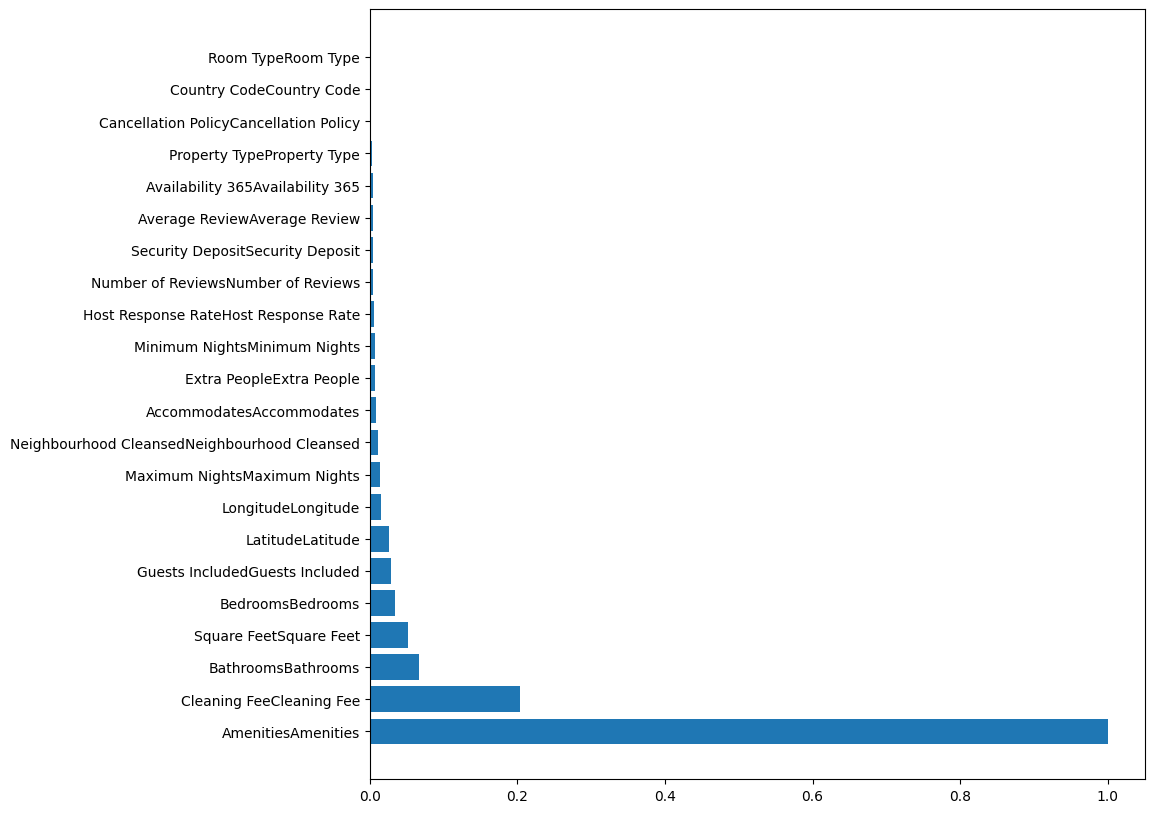

In [62]:
# Importancia de variables
s1= train_df.columns.drop(['Price'])
s2 = test_df.columns.drop(['Price'])
features = s1 + s2
bt = GradientBoostingClassifier(random_state=0, max_depth=2,learning_rate=lrOptimo, n_estimators=neOptimo)
bt.fit(X_train,y_train)
importances = bt.feature_importances_
importances = importances / np.max(importances)
importances

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),features[indices])
plt.show()

### *Conclusiones:*

*Como resultado, observamos una mejora significativa en el error del modelo, lo que confirma la eficacia de las estrategias implementadas con algoritmos mas robustos.*

   ***¡Una mejoría alcanzada!***
                                                    
*Aunque hemos probado diversos modelos y técnicas — incluyendo transformaciones polinomiales, kernels, boosting, random forest y bagging, el MSE sigue siendo relativamente alto y el rendimiento similar entre ellos. Esto nos indica que es momento de profundizar en el análisis y explorar nuevas estrategias para mejorar el modelo.*
- ***Algunas recomendaciones para avanzar son:***
   - *Reducir la cantidad de variables, ya que algunas pueden ser irrelevantes o generar sesgo.*
   - *Crear variables específicas para el problema, por ejemplo, “Precio por Extra People”.*
   - *Aplicar técnicas de selección de características para filtrar las variables más útiles.*
   - ***Tratamiento con tecnicas de NLP para variables textuales de valor potencial***
  
*Además, podemos destacar la importancia de las variables para el modelo, aunque el costo computacional de algunos algoritmos (en mi caso, hasta 73 minutos de ejecución) es alto y podría optimizarse con ajustes y selección de variables adicionales, así como una nueva revisión de outliers.*

*Para los objetivos de este proyecto, que incluyen el manejo adecuado de técnicas de Machine Learning, la exploración estadística, la creación y comparación de modelos, y una documentación clara, consideramos que este punto marca un cierre adecuado a la exploración.*


###                  ***¡Gracias por visitar y acompañarme en este proyecto!***